#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#RNA sequencing data

In [ ]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan/TCGA_Pan_TPM.csv', index_col = 0)
rna.index.name = None
rna = rna.T
rna = rna.fillna(0)
rna

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-D8-A146-01A-31R-A115-07,49.6341,9.3826,115.1737,20.1202,6.1859,10.9585,30.9154,47.9991,19.9032,56.4289,...,0.0,0.0,0.4513,0.0,0.0000,0.0000,10.5835,0.0,0.0411,1.1776
TCGA-AQ-A0Y5-01A-11R-A14M-07,12.0296,0.3785,134.9047,15.5758,4.3777,4.0015,29.7787,91.9948,15.5230,51.4084,...,0.0,0.0,0.1525,0.0,0.0000,0.0000,26.3496,0.0,0.0387,1.3672
TCGA-C8-A274-01A-11R-A16F-07,90.4249,0.0000,110.8229,31.8373,15.4869,3.3594,6.9632,33.7734,9.6288,61.4116,...,0.0,0.0,0.3309,0.0,0.0000,0.0000,25.0229,0.0,0.0669,0.5202
TCGA-BH-A0BD-01A-11R-A034-07,26.5679,4.0213,86.0077,19.7490,16.9112,7.7082,25.9960,47.7976,11.3436,50.2045,...,0.0,0.0,0.2042,0.0,0.9539,0.0000,24.7960,0.0,0.0423,0.4503
TCGA-B6-A1KC-01B-11R-A157-07,18.0535,0.3523,71.4260,10.7816,5.0191,1.8453,12.1971,36.3761,8.4625,61.0838,...,0.0,0.0,0.3510,0.0,0.0000,0.0000,34.9575,0.0,0.0166,0.3096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-CV-7432-01A-11R-2132-07,24.6081,0.0000,94.0782,3.0046,8.5726,1.6796,23.4212,49.3647,21.7065,27.7411,...,0.0,0.0,0.0387,0.0,0.0000,0.0000,8.8813,0.0,0.0115,0.5252
TCGA-IQ-7630-01A-11R-2081-07,20.2326,0.0000,140.2880,3.1163,4.2292,5.5204,17.6486,28.3515,22.3682,23.7656,...,0.0,0.0,0.1788,0.0,0.7595,0.0232,5.1276,0.0,0.0193,0.4688
TCGA-H7-A6C4-11A-21R-A466-07,10.5713,2.5236,46.0305,1.8369,0.4042,3.8626,21.7283,6.6741,7.2261,5.5616,...,0.0,0.0,0.0184,0.0,0.0000,0.0000,15.0684,0.0,0.0436,0.1874
TCGA-H7-8501-01A-11R-2403-07,21.6568,0.0668,216.4906,5.3968,8.7638,19.9276,68.5642,89.8720,10.7472,25.0787,...,0.0,0.0,0.1383,0.0,0.0000,0.0000,2.3447,0.0,0.0205,1.4076


In [ ]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-D8-A146-01A-31R-A115-07,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,0.0,0.0,0.537346,0.0,0.0,0.0,3.533999,0.0,0.058109,1.122739
TCGA-AQ-A0Y5-01A-11R-A14M-07,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,0.0,0.0,0.204767,0.0,0.0,0.0,4.773448,0.0,0.054779,1.243182
TCGA-C8-A274-01A-11R-A16F-07,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.0,0.0,0.412402,0.0,0.0,0.0,4.701710,0.0,0.093425,0.604261


#Import Ensemble

In [ ]:
#Import elastic net

import joblib

model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/ElasticNet.pkl')

In [ ]:
ensemble_features = model_1.feature_names_in_
ensemble_features

array(['ENSG00000198712', 'ENSG00000198804', 'ENSG00000198938', ...,
       'ENSG00000197838', 'ENSG00000167751', 'ENSG00000182415'],
      dtype=object)

In [ ]:
import pickle

with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_features.pkl', 'rb') as f:
    ensemble_y_train_features_loaded = pickle.load(f)

print(ensemble_y_train_features_loaded)

Index(['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)',
       '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)',
       '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)',
       '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)',
       '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)',
       ...
       'urea', 'uridine', 'valine', 'valylglycine', 'xanthine', 'xanthosine',
       '3-phosphoglycerate', 'dehydroascorbate', 'pyruvate',
       'phosphoenolpyruvate (PEP)'],
      dtype='object', length=218)


In [ ]:
#Import random forest regressor

model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Random Forest Regressor.pkl')

In [ ]:
#Import final estimator

final_estimator = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Ensemble.pkl')

#Import NN

In [ ]:
import joblib
import tensorflow as tf

In [ ]:
var_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_unbiased_features_nn_model.keras')

In [ ]:
var_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3030)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,103,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_dense (Dense)        │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,935,120 (15.01 MB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 3,767,040 (14.37 MB)

 Optimizer params: 112,054 (437.71 KB)

In [ ]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_unbiased_features_nn_model_features_input.pkl', 'rb') as f:
  var_model_input_features = pickle.load(f)

print(var_model_input_features)

['ENSG00000000005', 'ENSG00000000419', 'ENSG00000000971', 'ENSG00000001617', 'ENSG00000002549', 'ENSG00000002586', 'ENSG00000002726', 'ENSG00000002834', 'ENSG00000002933', 'ENSG00000003989', 'ENSG00000004059', 'ENSG00000004142', 'ENSG00000004478', 'ENSG00000004776', 'ENSG00000004779', 'ENSG00000004799', 'ENSG00000004939', 'ENSG00000005022', 'ENSG00000005075', 'ENSG00000005421', 'ENSG00000005486', 'ENSG00000005513', 'ENSG00000005884', 'ENSG00000006016', 'ENSG00000006125', 'ENSG00000006128', 'ENSG00000006210', 'ENSG00000006327', 'ENSG00000006659', 'ENSG00000006831', 'ENSG00000007080', 'ENSG00000007255', 'ENSG00000007306', 'ENSG00000007312', 'ENSG00000007350', 'ENSG00000007933', 'ENSG00000007952', 'ENSG00000008018', 'ENSG00000008282', 'ENSG00000008283', 'ENSG00000008394', 'ENSG00000008441', 'ENSG00000008517', 'ENSG00000008988', 'ENSG00000009307', 'ENSG00000009765', 'ENSG00000010256', 'ENSG00000010278', 'ENSG00000010438', 'ENSG00000010610', 'ENSG00000011009', 'ENSG00000011028', 'ENSG000000

In [ ]:
len(var_model_input_features)

3030

In [ ]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_unbiased_features_nn_model_features_output.pkl', 'rb') as f:
  var_model_output_features = pickle.load(f)

print(var_model_output_features)

['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)', '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)', '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)', '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)', '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)', '1-palmitoyl-GPC (16:0)', '1-palmitoyl-GPE (16:0)', '1-palmitoyl-GPI (16:0)', '1-(1-enyl-palmitoyl)-GPE (P-16:0)', '1-stearoyl-GPC (18:0)', '1-stearoyl-GPI (18:0)', '10-heptadecenoate (17:1n7)', '10-nonadecenoate (19:1n9)', '13-HODE + 9-HODE', 'methyl palmitate (15 or 2)', "2'-deoxyguanosine", "2'-deoxyinosine", '2-aminoadipate', '2-hydroxyglutarate', '2-hydroxypalmitate', '2-methylbutyroylcarnitine', '2-palmitoyl-GPC (16:0)', '3-(4-hydroxyphenyl)lactate', '3-aminoisobutyrate', '3-carboxy-4-methyl-5-propyl-2-furanpropanoate (CMPF)', '3-hydroxybutyrate (BHBA)', '3-indoxyl sulfate', '3-methyl-2-oxovalerate', '3-methylhistidine', '4-acetamidophenol', '4-acetaminophen sulfate', '4-androste

#Metabolite prediction functions

In [ ]:
metabolite_names = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_tissue_name_map.csv')
metabolite_names = metabolite_names.fillna('No_id')
metabolite_names

,Query,Match,HMDB,PubChem,ChEBI,KEGG,METLIN,SMILES,Comment
0,"1,5-anhydroglucitol (1,5-AG)",No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
1,1-arachidonoyl-GPC (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
2,1-arachidonoyl-GPE (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
3,1-arachidonoyl-GPI (20:4),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
4,1-linoleoylglycerol (18:2),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
...,...,...,...,...,...,...,...,...,...
213,xanthosine,Xanthosine,HMDB0000299,64959.0,18107.0,C01762,3408.0,OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=NC2=C1N=C(...,1
214,3-phosphoglycerate,3-Phosphoglyceric acid,HMDB0000807,724.0,17050.0,C00597,150.0,OC(COP(O)(O)=O)C(O)=O,1
215,dehydroascorbate,Dehydroascorbic acid,HMDB0001264,440667.0,27956.0,C05422,342.0,[H][C@@]1(OC(=O)C(=O)C1=O)[C@@H](O)CO,1
216,pyruvate,Pyruvic acid,HMDB0000243,1060.0,32816.0,C00022,117.0,CC(=O)C(O)=O,1


In [ ]:
metabolite_name_dict = dict(zip(metabolite_names['Query'], metabolite_names['HMDB']))
metabolite_name_dict

{'1,5-anhydroglucitol (1,5-AG)': 'No_id',
 '1-arachidonoyl-GPC (20:4n6)': 'No_id',
 '1-arachidonoyl-GPE (20:4n6)': 'No_id',
 '1-arachidonoyl-GPI (20:4)': 'No_id',
 '1-linoleoylglycerol (18:2)': 'No_id',
 '1-linoleoyl-GPC (18:2)': 'HMDB0010386',
 '1-oleoylglycerol (1-monoolein)': 'HMDB0011567',
 '1-oleoyl-GPE (18:1)': 'No_id',
 '1-palmitoleoyl-GPC (16:1)': 'No_id',
 '1-palmitoylglycerol (1-monopalmitin)': 'No_id',
 '1-palmitoyl-GPC (16:0)': 'HMDB0010382',
 '1-palmitoyl-GPE (16:0)': 'HMDB0011503',
 '1-palmitoyl-GPI (16:0)': 'No_id',
 '1-(1-enyl-palmitoyl)-GPE (P-16:0)': 'No_id',
 '1-stearoyl-GPC (18:0)': 'No_id',
 '1-stearoyl-GPI (18:0)': 'No_id',
 '10-heptadecenoate (17:1n7)': 'HMDB0060038',
 '10-nonadecenoate (19:1n9)': 'HMDB0013622',
 '13-HODE + 9-HODE': 'No_id',
 'methyl palmitate (15 or 2)': 'HMDB0061709',
 "2'-deoxyguanosine": 'HMDB0000085',
 "2'-deoxyinosine": 'HMDB0000071',
 '2-aminoadipate': 'HMDB0000510',
 '2-hydroxyglutarate': 'HMDB0059655',
 '2-hydroxypalmitate': 'HMDB0031057

In [ ]:
def normalize(df):
  data = df.copy()
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

In [ ]:
#Ensemble predictions

def predict_metabolites_ensemble(model_1, model_2, final_estimator, df, input_features, output_features, output_features_to_keep):
  df = df.reindex(input_features, axis = 'columns')
  pred_1 = model_1.predict(df)
  pred_2 = model_2.predict(df)
  stacked_preds = np.hstack([pred_1, pred_2])
  pred_metabolites = final_estimator.predict(stacked_preds)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = df.index, columns = output_features)
  pred_metabolites = pred_metabolites.rename(columns = metabolite_name_dict)
  pred_metabolites = pred_metabolites.drop(columns = ['No_id'])
  pred_metabolites = pred_metabolites[output_features_to_keep]

  return pred_metabolites

In [ ]:
def nn_predict(model, df, input_features, output_features, output_features_to_keep):
  data = df.copy()
  data = data.reindex(input_features, axis = 'columns')
  data = normalize(data)
  data = pd.DataFrame(data, index = df.index, columns = input_features)

  predictions = model.predict(data)
  predictions = pd.DataFrame(predictions, index = data.index, columns = output_features)
  predictions = predictions.rename(columns = metabolite_name_dict)
  predictions = predictions.drop(columns = ['No_id'])
  predictions = predictions[output_features_to_keep]

  return predictions

#Metabolite prediction

In [4]:
import pickle

In [ ]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/total_metabolites_predicted.pkl', 'rb') as file:
  correct_mets = pickle.load(file)

correct_mets

In [22]:
mets_to_save = []
for key, value_list in correct_mets.items():
  mets_to_save.extend(value_list)

len(mets_to_save)

72

In [23]:
mets_to_save.sort()
mets_to_save

['HMDB0000043',
 'HMDB0000064',
 'HMDB0000071',
 'HMDB0000086',
 'HMDB0000089',
 'HMDB0000097',
 'HMDB0000123',
 'HMDB0000125',
 'HMDB0000126',
 'HMDB0000134',
 'HMDB0000139',
 'HMDB0000156',
 'HMDB0000157',
 'HMDB0000159',
 'HMDB0000162',
 'HMDB0000163',
 'HMDB0000167',
 'HMDB0000168',
 'HMDB0000177',
 'HMDB0000182',
 'HMDB0000191',
 'HMDB0000195',
 'HMDB0000201',
 'HMDB0000210',
 'HMDB0000211',
 'HMDB0000224',
 'HMDB0000251',
 'HMDB0000252',
 'HMDB0000254',
 'HMDB0000262',
 'HMDB0000267',
 'HMDB0000283',
 'HMDB0000289',
 'HMDB0000299',
 'HMDB0000300',
 'HMDB0000517',
 'HMDB0000532',
 'HMDB0000562',
 'HMDB0000625',
 'HMDB0000641',
 'HMDB0000660',
 'HMDB0000673',
 'HMDB0000684',
 'HMDB0000695',
 'HMDB0000696',
 'HMDB0000714',
 'HMDB0000759',
 'HMDB0000767',
 'HMDB0000806',
 'HMDB0000812',
 'HMDB0000826',
 'HMDB0000827',
 'HMDB0000848',
 'HMDB0000870',
 'HMDB0000929',
 'HMDB0000939',
 'HMDB0000939',
 'HMDB0000943',
 'HMDB0001173',
 'HMDB0001316',
 'HMDB0001348',
 'HMDB0001406',
 'HMDB00

In [25]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/total_metabolites_predicted.txt', 'w') as file:
    for item in mets_to_save:
        file.write(f"{item}\n")

In [ ]:
ensemble_metabolites = predict_metabolites_ensemble(model_1 = model_1,
                                                    model_2 = model_2,
                                                    final_estimator = final_estimator,
                                                    df = rna,
                                                    input_features = ensemble_features,
                                                    output_features = ensemble_y_train_features_loaded,
                                                    output_features_to_keep = correct_mets['Ensemble'])
ensemble_metabolites.head(3)

In [ ]:
ensemble_metabolites[['HMDB0000759']]

,HMDB0000759,HMDB0000759
TCGA-D8-A146-01A-31R-A115-07,17.060655,16.771612
TCGA-AQ-A0Y5-01A-11R-A14M-07,17.834272,16.788446
TCGA-C8-A274-01A-11R-A16F-07,16.836549,16.010376
TCGA-BH-A0BD-01A-11R-A034-07,17.533550,16.156929
TCGA-B6-A1KC-01B-11R-A157-07,16.880097,15.950429
...,...,...
TCGA-CV-7432-01A-11R-2132-07,16.555072,15.736055
TCGA-IQ-7630-01A-11R-2081-07,16.162896,15.678527
TCGA-H7-A6C4-11A-21R-A466-07,16.036778,15.771578
TCGA-H7-8501-01A-11R-2403-07,16.356581,15.897669


In [ ]:
nn_metabolites = nn_predict(model = var_model,
                            df = rna,
                            input_features = var_model_input_features,
                            output_features = var_model_output_features,
                            output_features_to_keep = correct_mets['Deep_learning_unbiased_features'])
nn_metabolites.head(3)

min: -1.0
max: 1.0
shape: (10668, 3030)
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,HMDB0000195,HMDB0000064,HMDB0000097,HMDB0000177,HMDB0000167,HMDB0000224,HMDB0000126,HMDB0000254,HMDB0000767,HMDB0028691,...,HMDB0000283,HMDB0000211,HMDB0001565,HMDB0000943,HMDB0000125,HMDB0000123,HMDB0000267,HMDB0000299,HMDB0000157,HMDB0000168
TCGA-D8-A146-01A-31R-A115-07,-0.032894,0.054465,-0.037997,-0.158925,0.051852,-0.156716,0.010380,-0.096495,-0.326387,-0.319198,...,-0.258636,0.257492,-0.010223,-0.096002,-0.219242,0.277909,-0.122200,-0.418882,-0.128857,-0.126260
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.194649,0.449961,0.417013,0.048748,0.324126,0.158175,0.111776,0.165179,-0.206344,-0.347735,...,-0.194185,0.434288,0.406766,0.164628,-0.139056,0.430182,0.115403,-0.273673,0.167726,0.306966
TCGA-C8-A274-01A-11R-A16F-07,0.135185,0.354842,0.314464,-0.025243,0.261226,0.063950,0.077446,0.087768,-0.274026,-0.367831,...,-0.221839,0.408177,0.298271,0.085953,-0.187823,0.399213,0.048301,-0.334960,0.087638,0.201477


In [ ]:
from sklearn.preprocessing import MinMaxScaler

def min_max(df):
  data = df.copy()
  scaler = MinMaxScaler(feature_range=(-1, 1))
  data = scaler.fit_transform(data)
  data = pd.DataFrame(data, index = df.index, columns = df.columns)

  return data

ensemble_metabolites = min_max(ensemble_metabolites)
print(np.max(ensemble_metabolites), np.min(ensemble_metabolites))

nn_metabolites = min_max(nn_metabolites)
print(np.max(nn_metabolites), np.min(nn_metabolites))

1.0000000000000009 -1.0000000000000004
1.000000238418579 -1.0


In [ ]:
drop_mets = list(set(ensemble_metabolites.columns).intersection(set(nn_metabolites.columns)))
len(drop_mets)

2

Metabolite: HMDB0028691, Spearman correlation: 0.1909, p-value: 0.0000


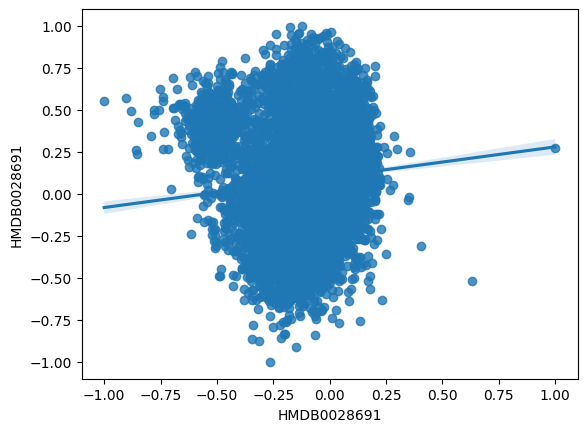

Metabolite: HMDB0000939, Spearman correlation: -0.0206, p-value: 0.0331


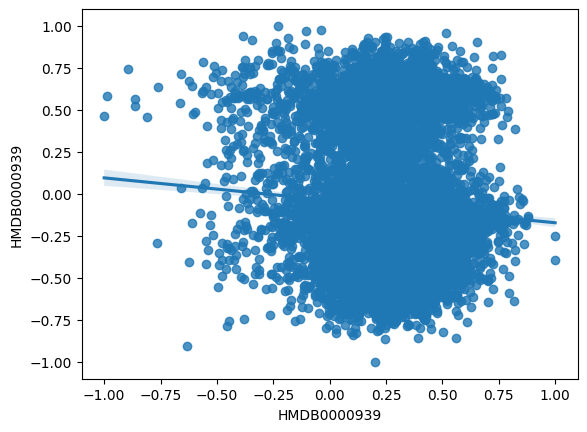

In [ ]:
#Spearman's correlation between the two prediction methods for these 2 metabolites
from scipy.stats import spearmanr

for i in drop_mets:
  correlation, pvalue = spearmanr(ensemble_metabolites[i], nn_metabolites[i])
  print(f"Metabolite: {i}, Spearman correlation: {correlation:.4f}, p-value: {pvalue:.4f}")
  sns.regplot(x = ensemble_metabolites[i], y = nn_metabolites[i])
  plt.show()

In [ ]:
#Drop from predictions the NN metabolites tha are common - manual inspection of R2 and Spearman's for these showed higher values in Ensemble model
nn_metabolites = nn_metabolites.drop(columns = drop_mets)
display(nn_metabolites.head(3))

,HMDB0000195,HMDB0000064,HMDB0000097,HMDB0000177,HMDB0000167,HMDB0000224,HMDB0000126,HMDB0000254,HMDB0000767,HMDB0000163,...,HMDB0000283,HMDB0000211,HMDB0001565,HMDB0000943,HMDB0000125,HMDB0000123,HMDB0000267,HMDB0000299,HMDB0000157,HMDB0000168
TCGA-D8-A146-01A-31R-A115-07,-0.714121,-0.689916,-0.737000,-0.726042,-0.633905,-0.760473,-0.906946,-0.802522,-0.526328,0.149169,...,-0.816832,-0.671293,-0.756128,-0.680072,-0.140197,-0.641231,-0.708907,-0.740135,-0.726478,-0.749646
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.450131,0.520845,0.571068,0.237421,0.440514,0.572131,-0.043986,0.273616,0.230798,-0.293108,...,-0.173996,0.837231,0.583765,0.420965,0.379359,0.596699,0.310625,0.240439,0.392764,0.497721
TCGA-C8-A274-01A-11R-A16F-07,0.145873,0.229651,0.276258,-0.105849,0.192304,0.173373,-0.336164,-0.044739,-0.196083,-0.235603,...,-0.449821,0.614434,0.235143,0.088601,0.063380,0.344933,0.022700,-0.173421,0.090531,0.193992


In [ ]:
metabolites = pd.concat([ensemble_metabolites, nn_metabolites], axis = 'columns')
metabolites.head(3)

,HMDB0000870,HMDB0000848,HMDB0000714,HMDB0000191,HMDB0000251,HMDB0003229,HMDB0000562,HMDB0000252,HMDB0000696,HMDB0000641,...,HMDB0000283,HMDB0000211,HMDB0001565,HMDB0000943,HMDB0000125,HMDB0000123,HMDB0000267,HMDB0000299,HMDB0000157,HMDB0000168
TCGA-D8-A146-01A-31R-A115-07,0.472328,0.074234,-0.226336,0.124093,0.269272,0.135733,-0.094486,-0.214091,0.134839,-0.052115,...,-0.816832,-0.671293,-0.756128,-0.680072,-0.140197,-0.641231,-0.708907,-0.740135,-0.726478,-0.749646
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.399344,-0.107610,-0.163713,-0.016701,0.022655,0.271255,0.019485,-0.050806,0.143165,0.058192,...,-0.173996,0.837231,0.583765,0.420965,0.379359,0.596699,0.310625,0.240439,0.392764,0.497721
TCGA-C8-A274-01A-11R-A16F-07,0.370598,0.020797,-0.194447,0.063527,0.222715,0.027229,-0.139715,-0.168199,-0.130246,-0.150252,...,-0.449821,0.614434,0.235143,0.088601,0.063380,0.344933,0.022700,-0.173421,0.090531,0.193992


In [ ]:
metabolites = metabolites.drop(columns = 'HMDB0000759') #annotation of metabolite names produce same HMDB ID, drop this
metabolites.head(3)

,HMDB0000870,HMDB0000848,HMDB0000714,HMDB0000191,HMDB0000251,HMDB0003229,HMDB0000562,HMDB0000252,HMDB0000696,HMDB0000641,...,HMDB0000283,HMDB0000211,HMDB0001565,HMDB0000943,HMDB0000125,HMDB0000123,HMDB0000267,HMDB0000299,HMDB0000157,HMDB0000168
TCGA-D8-A146-01A-31R-A115-07,0.472328,0.074234,-0.226336,0.124093,0.269272,0.135733,-0.094486,-0.214091,0.134839,-0.052115,...,-0.816832,-0.671293,-0.756128,-0.680072,-0.140197,-0.641231,-0.708907,-0.740135,-0.726478,-0.749646
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.399344,-0.107610,-0.163713,-0.016701,0.022655,0.271255,0.019485,-0.050806,0.143165,0.058192,...,-0.173996,0.837231,0.583765,0.420965,0.379359,0.596699,0.310625,0.240439,0.392764,0.497721
TCGA-C8-A274-01A-11R-A16F-07,0.370598,0.020797,-0.194447,0.063527,0.222715,0.027229,-0.139715,-0.168199,-0.130246,-0.150252,...,-0.449821,0.614434,0.235143,0.088601,0.063380,0.344933,0.022700,-0.173421,0.090531,0.193992


In [ ]:
metabolites.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/TCGA_metabolites_ensemble_nn_predicted.csv', index = True)